In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import *
import seaborn as sns
import statsmodels.formula.api as smf



In [2]:
#Use the mpg dataset
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv'

df = pd.read_csv(url)
df = df.dropna()

In [3]:
df = df.iloc[:,:7]

In [4]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70
...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82
394,44.0,4,97.0,52.0,2130,24.6,82
395,32.0,4,135.0,84.0,2295,11.6,82
396,28.0,4,120.0,79.0,2625,18.6,82


Text(0.5, 1.0, 'Correlation Matrix')

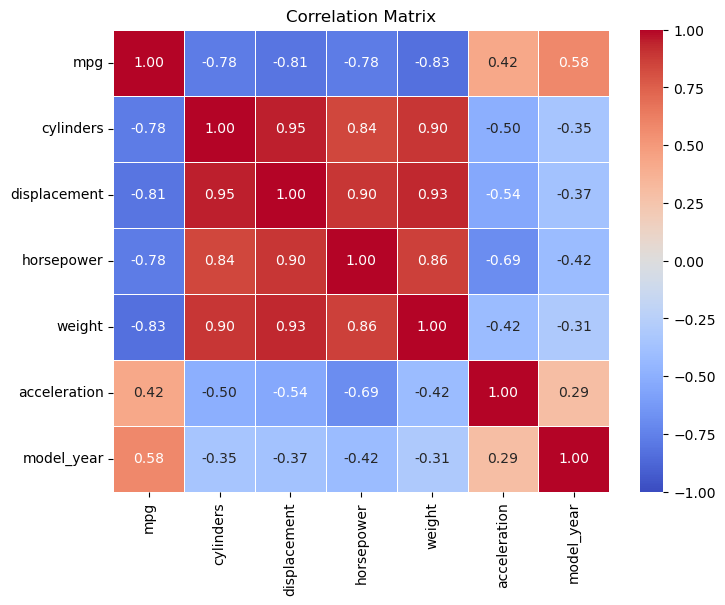

In [5]:
correlation_matrix = df.corr()


plt.figure(figsize=(8, 6))


sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,vmin=-1,vmax=1)

plt.title('Correlation Matrix')

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

import statsmodels.api as sm

In [7]:
X = df[[
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year"
]]

In [8]:
# Add intercept term
X_const = sm.add_constant(X)

# Compute VIF for each feature
vif = pd.DataFrame()
vif["variable"] = X_const.columns
vif["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

print(vif)

       variable         VIF
0         const  753.863747
1     cylinders   10.633049
2  displacement   19.641683
3    horsepower    9.398043
4        weight   10.731681
5  acceleration    2.625581
6    model_year    1.244829


In [9]:
X_new = df[[

    "horsepower",

    "acceleration",
    "model_year"
]]

In [10]:
# Add intercept term
X_const = sm.add_constant(X_new)

# Compute VIF for each feature
vif = pd.DataFrame()
vif["variable"] = X_const.columns
vif["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

print(vif)

       variable         VIF
0         const  687.426619
1    horsepower    2.110023
2  acceleration    1.904777
3    model_year    1.209743


In [11]:

# Fit linear model
model = sm.OLS(df["mpg"], X_const).fit()

# Summary
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     317.2
Date:                Mon, 26 Jan 2026   Prob (F-statistic):          5.37e-104
Time:                        14:15:00   Log-Likelihood:                -1118.3
No. Observations:                 392   AIC:                             2245.
Df Residuals:                     388   BIC:                             2261.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.1492      5.584     -0.027      0.979     -11.128      10.830
horsepower      -0.1620      0.008    -20.127      0.000      -0.178      -0.146
acceleration    -0.6154      0.107     -5.769      0.000      -0.825      -0.406
model_year       0.6591      0.064     10.352      0.000       0.534       0.784
==============================================================================
Omnibus:                       35.054   Durbin-Watson:                   1.157
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               44.578
Skew:                           0.692   Prob(JB):                     2.09e-10
Kurtosis:                       3.901   Cond. No.                     3.50e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.5e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""